In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
csv_path = '/content/drive/MyDrive/dataset/autoencoder_regression_dataset.csv'

# Load the dataset
df = pd.read_csv(csv_path)
data = df.to_numpy()

# Display shape
print("Shape:", df.shape)
df.head()

Shape: (98664, 18)


,auto1,auto2,auto3,auto4,auto5,auto6,auto7,auto8,R_p,g_p,Temp,log_kappa_cloud,log_P_cloud,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,-6.900868,-2.257141,0.207701,4.832452,3.164491,-3.497359,-0.399868,-3.593274,1.658348,17.176982,3327.875478,-3.855474,-3.844470,-8.889865,-4.018888,-3.195541,-7.868857,-5.895533
1,-1.916458,-3.192332,-2.223765,5.931571,4.592133,-4.370333,0.607382,-0.963816,0.258443,16.036432,2034.071133,-3.014919,-2.962217,-3.225697,-2.038615,-5.329029,-3.169883,-3.206833
2,-2.968401,-4.461657,0.615572,6.173611,3.366025,-3.686306,1.251608,-2.651082,0.503774,9.066010,1712.661454,-2.246068,-1.677456,-3.993484,-2.895214,-7.397882,-8.908273,-7.172669
3,-6.847833,-1.085600,1.159278,6.646182,2.965960,-3.345752,1.183463,-3.545845,0.562965,7.254639,3287.260930,-1.086659,-3.761693,-8.448541,-3.301345,-4.516020,-7.289866,-7.753208
4,-6.317009,-2.666278,0.357277,5.979415,3.764004,-3.740373,0.478526,-2.697041,0.745250,35.230361,2895.010899,-1.323324,-1.794849,-8.350682,-4.666140,-6.680365,-6.197769,-5.475105


In [ ]:
df.describe()

,auto1,auto2,auto3,auto4,auto5,auto6,auto7,auto8,R_p,g_p,Temp,log_kappa_cloud,log_P_cloud,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
count,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000
mean,0.432125,-3.457424,-3.516597,3.565911,4.389943,-3.945479,0.114160,-1.418761,1.060991,22.680367,1990.529089,-3.203587,-1.506352,-5.497066,-5.490777,-5.500600,-5.500026,-5.508865
std,3.234254,1.967700,3.186135,1.796521,1.560807,1.812092,2.572931,1.960795,0.542885,10.043365,866.480792,2.187283,1.445999,2.021719,2.020946,2.027659,2.023330,2.020505
min,-14.811619,-15.821565,-34.447407,-10.412514,-0.998671,-8.042172,-17.367699,-17.314592,0.100042,5.000412,500.059513,-6.999982,-3.999971,-8.999924,-8.999969,-8.999911,-8.999990,-8.999985
25%,-1.607159,-4.582289,-4.866113,2.445690,3.396904,-5.127968,-1.442510,-2.488036,0.593661,14.036827,1238.898762,-5.087822,-2.762471,-7.250021,-7.239419,-7.264763,-7.260083,-7.261356
50%,1.228101,-3.437524,-2.951968,3.444859,4.215981,-4.415377,0.642672,-1.233767,1.061147,22.724996,1986.033911,-3.215291,-1.504305,-5.488896,-5.485339,-5.499874,-5.502937,-5.508495
75%,2.808834,-2.111875,-1.699876,4.814338,5.243215,-3.260385,2.143631,-0.132477,1.531775,31.344526,2737.571477,-1.317402,-0.255494,-3.753459,-3.741738,-3.740803,-3.745523,-3.763974
max,8.470268,1.421151,3.338503,8.002897,16.989565,12.363155,5.335825,3.258902,1.999990,39.999593,3499.933503,0.599861,0.999957,-2.000011,-2.000260,-2.000041,-2.000107,-2.000021


In [ ]:
def prepare_data(df, target_col, test_size=0.2, val_size=0.5, random_state=42):
    """
    Prepares data for the classical model: splits, scales, and converts to torch tensors.

    Args:
        df (pd.DataFrame): Input dataframe.
        target_col (str): Name of the target column.
        test_size (float): Fraction of total data for testing.
        val_size (float): Fraction of temporary split to use as validation.
        random_state (int): Random seed for reproducibility.

    Returns:
        X_train_t, X_val_t, X_test_t (torch.Tensor): Scaled feature tensors.
        y_train_t, y_val_t, y_test_t (torch.Tensor): Scaled target tensors.
        scaler_X (StandardScaler): Fitted scaler for features.
        scaler_y (StandardScaler): Fitted scaler for target.
    """

    X = df.iloc[:, :8].values.astype(np.float32)
    y = df[[target_col]].values.astype(np.float32)

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=test_size, random_state=random_state)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=val_size, random_state=random_state)

    scaler_X = StandardScaler()
    X_train = scaler_X.fit_transform(X_train)
    X_val   = scaler_X.transform(X_val)
    X_test  = scaler_X.transform(X_test)

    # Scale target
    scaler_y = StandardScaler()
    y_train = scaler_y.fit_transform(y_train)
    y_val   = scaler_y.transform(y_val)
    y_test  = scaler_y.transform(y_test)

    # Convert to torch tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    y_val_t   = torch.tensor(y_val, dtype=torch.float32)
    y_test_t  = torch.tensor(y_test, dtype=torch.float32)

    return X_train_t, X_val_t, X_test_t, y_train_t, y_val_t, y_test_t, scaler_X, scaler_y

In [ ]:
def build_classical_model(input_dim=8):
    """
    Builds the classical fusion regressor model similar to H2O hybrid structure.

    Args:
        input_dim (int): Number of input features i.e '8' autoencoded spectral features.

    Returns:
        model (nn.Module): PyTorch classical regression model.
    """
    class Regressor(nn.Module):
        def __init__(self):
            super().__init__()
            # Classical branch
            self.fc1 = nn.Linear(input_dim, 64)
            self.bn1 = nn.BatchNorm1d(64)
            self.fc2 = nn.Linear(64, 32)
            self.bn2 = nn.BatchNorm1d(32)

            self.q_fc1 = nn.Linear(input_dim, 16)
            self.q_fc2 = nn.Linear(16, 3)
            # Fusion
            self.fc_fuse1 = nn.Linear(32 + 3, 32)
            self.fc_fuse2 = nn.Linear(32, 1)

        def forward(self, x):
            c = F.relu(self.bn1(self.fc1(x)))
            c = F.relu(self.bn2(self.fc2(c)))
            q = F.relu(self.q_fc1(x))
            q = self.q_fc2(q)
            x = torch.cat([c, q], dim=1)
            x = F.relu(self.fc_fuse1(x))
            out = self.fc_fuse2(x)
            return out

    model = Regressor()
    return model

In [ ]:
def train_classical_model(model, train_loader, val_loader,
                          target_name, epochs=300, lr=0.0005, patience=30,
                          save_dir="/content/drive/MyDrive/"):
    """
    Trains the classical fusion model with early stopping.

    Args:
        model (nn.Module): PyTorch classical model.
        train_loader, val_loader (DataLoader): DataLoaders for training and validation.
        target_name (str): Name of the target variable.
        epochs (int): Maximum number of epochs.
        lr (float): Learning rate.
        patience (int): Early stopping patience.
        save_dir (str): Directory to save the best model weights.

    Returns:
        model (nn.Module): Trained model with best weights loaded.
        history (dict): Training history with 'loss', 'val_loss', 'mae', 'val_mae'.
    """
    optimizer = Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    save_path = f"{save_dir}classical_best_{target_name}.pth"

    best_val_loss = float("inf")
    wait = 0
    history = {"loss": [], "val_loss": [], "mae": [], "val_mae": []}

    for epoch in range(epochs):
        model.train()
        train_losses, train_mae = [], []

        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            train_mae.append(torch.mean(torch.abs(preds - yb)).item())

        model.eval()
        val_losses, val_mae = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                preds = model(xb)
                val_losses.append(loss_fn(preds, yb).item())
                val_mae.append(torch.mean(torch.abs(preds - yb)).item())

        train_loss, val_loss = np.mean(train_losses), np.mean(val_losses)
        train_mae, val_mae = np.mean(train_mae), np.mean(val_mae)

        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["mae"].append(train_mae)
        history["val_mae"].append(val_mae)

        print(f"Epoch {epoch+1}/{epochs}, "
              f"Train MSE={train_loss:.4f}, Val MSE={val_loss:.4f}, "
              f"Train MAE={train_mae:.4f}, Val MAE={val_mae:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            torch.save(model.state_dict(), save_path)
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered")
                break

    model.load_state_dict(torch.load(save_path))
    model.eval()
    return model, history


In [ ]:
def compute_metrics(model, X_test, y_test, scaler_y=None):
    """
    Computes RMSE, MAE, and R2 for a trained classical model on the test set.

    Args:
        model (nn.Module): Trained classical model.
        X_test (torch.Tensor): Test features.
        y_test (torch.Tensor): Test targets.
        scaler_y (sklearn Scaler, optional): If provided, inverse transforms y for metrics.

    Returns:
        metrics (dict): Dictionary with 'rmse', 'mae', 'r2'.
        y_pred_rescaled (np.ndarray): Model predictions as numpy array .
        y_true_rescaled (np.ndarray): True targets .
    """
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test).numpy()
        y_true = y_test.numpy()

    if scaler_y is not None:
        y_pred_rescaled = scaler_y.inverse_transform(y_pred)
        y_true_rescaled = scaler_y.inverse_transform(y_true)
    else:
        y_pred_rescaled = y_pred
        y_true_rescaled = y_true

    metrics = {
        "rmse": np.sqrt(mean_squared_error(y_true_rescaled, y_pred_rescaled)),
        "mae": mean_absolute_error(y_true_rescaled, y_pred_rescaled),
        "r2": r2_score(y_true_rescaled, y_pred_rescaled)
    }

    print(f"\nTest Metrics:")
    print(f"RMSE={metrics['rmse']:.3f}, MAE={metrics['mae']:.3f}, R²={metrics['r2']:.3f}")

    return metrics, y_pred_rescaled, y_true_rescaled

In [ ]:
def plot_results(history, y_true, y_pred, target_name):
    """
    Plots training curves (MSE & MAE) and scatter plot of true vs predicted for classical model.

    Args:
        history (dict): Training history with keys 'loss', 'val_loss', 'mae', 'val_mae'.
        y_true (np.ndarray): True target values .
        y_pred (np.ndarray): Predicted target values .
        target_name (str): Name of the target parameter .
    """
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # MSE
    axes[0].plot(history['loss'], label='Train MSE')
    axes[0].plot(history['val_loss'], label='Val MSE')
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("MSE")
    axes[0].set_title(f"MSE Curve ({target_name})")
    axes[0].legend()

    # MAE
    axes[1].plot(history['mae'], label='Train MAE')
    axes[1].plot(history['val_mae'], label='Val MAE')
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("MAE")
    axes[1].set_title(f"MAE Curve ({target_name})")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print("\n" * 5)

    # Scatter plot: True vs Predicted
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel(f"True {target_name}")
    plt.ylabel(f"Predicted {target_name}")
    plt.title(f"True vs Predicted ({target_name})")
    plt.show()


In [ ]:
def predict_random_samples(model, X_test, y_test, scaler_y=None, n_samples=20):
    """
    Prints predictions for random test samples.

    Args:
        model (nn.Module): Trained classical model.
        X_test (torch.Tensor): Test features.
        y_test (torch.Tensor): Test targets.
        scaler_y (sklearn Scaler, optional): If provided, inverse transforms y for predictions.
        n_samples (int): Number of random samples to show.

    Returns:
        None
    """
    model.eval()
    idx = np.random.choice(len(X_test), size=n_samples, replace=False)
    with torch.no_grad():
        y_pred = model(X_test[idx]).numpy()
        y_true = y_test[idx].numpy()

    if scaler_y is not None:
        y_pred = scaler_y.inverse_transform(y_pred)
        y_true = scaler_y.inverse_transform(y_true)

    print(f"\nPredictions for {n_samples} Random Test Samples:")
    for i in range(n_samples):
        print(f"Sample {i+1}: True={y_true[i,0]:.4f}, Pred={y_pred[i,0]:.4f}")

# **log_H2O**

In [ ]:
# Target: log_H2O
target = "log_H2O"

# 1. Prepare data
X_train, X_val, X_test, y_train, y_val, y_test, scaler_X, scaler_y = prepare_data(df, target)

# 2. Create DataLoaders
batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)

# 3. Build the classical model
model = build_classical_model(input_dim=8)

In [ ]:
# 4. Train the classical model
model, history = train_classical_model(model, train_loader, val_loader, target_name=target,
                                       epochs=300, lr=0.0005, patience=30, save_dir="/content/drive/MyDrive/")

Epoch 1/300, Train MSE=0.3131, Val MSE=0.2020, Train MAE=0.4335, Val MAE=0.3462
Epoch 2/300, Train MSE=0.2205, Val MSE=0.1860, Train MAE=0.3559, Val MAE=0.3276
Epoch 3/300, Train MSE=0.2089, Val MSE=0.1799, Train MAE=0.3435, Val MAE=0.3179
Epoch 4/300, Train MSE=0.1971, Val MSE=0.1712, Train MAE=0.3324, Val MAE=0.3089
Epoch 5/300, Train MSE=0.1940, Val MSE=0.1670, Train MAE=0.3281, Val MAE=0.3057
Epoch 6/300, Train MSE=0.1884, Val MSE=0.1652, Train MAE=0.3219, Val MAE=0.2997
Epoch 7/300, Train MSE=0.1860, Val MSE=0.1623, Train MAE=0.3187, Val MAE=0.2987
Epoch 8/300, Train MSE=0.1817, Val MSE=0.1576, Train MAE=0.3143, Val MAE=0.2925
Epoch 9/300, Train MSE=0.1794, Val MSE=0.1571, Train MAE=0.3115, Val MAE=0.2899
Epoch 10/300, Train MSE=0.1791, Val MSE=0.1590, Train MAE=0.3105, Val MAE=0.2913
Epoch 11/300, Train MSE=0.1727, Val MSE=0.1552, Train MAE=0.3052, Val MAE=0.2873
Epoch 12/300, Train MSE=0.1686, Val MSE=0.1545, Train MAE=0.3007, Val MAE=0.2920
Epoch 13/300, Train MSE=0.1692, Val M

In [ ]:
# 5. Compute test metrics
metrics, y_pred_rescaled, y_true_rescaled = compute_metrics(model, X_test, y_test, scaler_y=scaler_y)


Test Metrics:
RMSE=0.681, MAE=0.476, R²=0.888


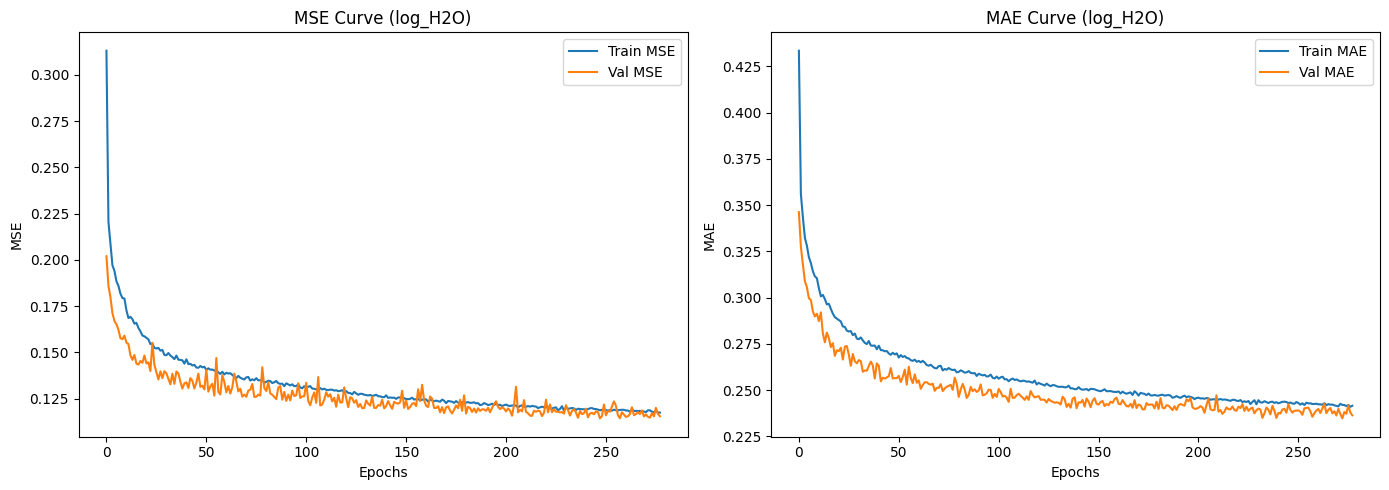

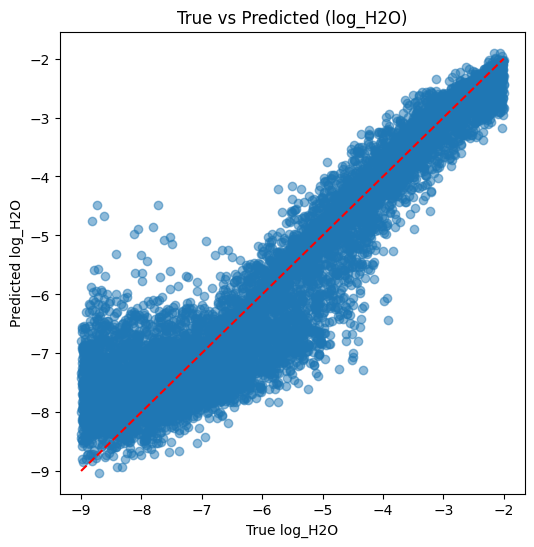

In [ ]:
# 6. Plot training curves and predictions
plot_results(history, y_true_rescaled, y_pred_rescaled, target_name=target)


In [ ]:

# 7. Predict random test samples
predict_random_samples(model, X_test, y_test, scaler_y=scaler_y, n_samples=20)


Predictions for 20 Random Test Samples:
Sample 1: True=-3.8958, Pred=-3.1455
Sample 2: True=-2.9595, Pred=-2.8233
Sample 3: True=-4.0471, Pred=-3.6116
Sample 4: True=-3.4861, Pred=-3.7862
Sample 5: True=-7.8050, Pred=-7.9759
Sample 6: True=-6.9102, Pred=-7.2625
Sample 7: True=-5.0535, Pred=-6.5149
Sample 8: True=-8.3604, Pred=-7.4453
Sample 9: True=-8.1237, Pred=-6.4059
Sample 10: True=-6.0703, Pred=-5.8289
Sample 11: True=-2.9941, Pred=-3.6675
Sample 12: True=-4.4560, Pred=-4.1430
Sample 13: True=-7.0100, Pred=-7.2924
Sample 14: True=-8.2025, Pred=-7.9568
Sample 15: True=-6.4546, Pred=-7.4882
Sample 16: True=-7.9890, Pred=-8.0152
Sample 17: True=-8.3227, Pred=-7.8346
Sample 18: True=-5.1333, Pred=-4.8791
Sample 19: True=-6.9368, Pred=-7.1918
Sample 20: True=-2.1718, Pred=-2.6448


# **log_CO2**

In [ ]:
target = "log_CO2"

# 1. Prepare data
X_train, X_val, X_test, y_train, y_val, y_test, scaler_X, scaler_y = prepare_data(df, target)

# 2. Create DataLoaders
batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)

# 3. Build the classical model
model = build_classical_model(input_dim=8)

In [ ]:
# 4. Train the classical model
model, history = train_classical_model(model, train_loader, val_loader, target_name=target,
                                       epochs=300, lr=0.0005, patience=30, save_dir="/content/drive/MyDrive/")

Epoch 1/300, Train MSE=0.1769, Val MSE=0.0929, Train MAE=0.3144, Val MAE=0.2371
Epoch 2/300, Train MSE=0.0934, Val MSE=0.0753, Train MAE=0.2340, Val MAE=0.2087
Epoch 3/300, Train MSE=0.0862, Val MSE=0.0736, Train MAE=0.2229, Val MAE=0.2033
Epoch 4/300, Train MSE=0.0793, Val MSE=0.0703, Train MAE=0.2122, Val MAE=0.1990
Epoch 5/300, Train MSE=0.0736, Val MSE=0.0623, Train MAE=0.2032, Val MAE=0.1856
Epoch 6/300, Train MSE=0.0717, Val MSE=0.0631, Train MAE=0.2003, Val MAE=0.1875
Epoch 7/300, Train MSE=0.0683, Val MSE=0.0602, Train MAE=0.1946, Val MAE=0.1825
Epoch 8/300, Train MSE=0.0657, Val MSE=0.0575, Train MAE=0.1905, Val MAE=0.1778
Epoch 9/300, Train MSE=0.0641, Val MSE=0.0586, Train MAE=0.1876, Val MAE=0.1793
Epoch 10/300, Train MSE=0.0614, Val MSE=0.0536, Train MAE=0.1833, Val MAE=0.1710
Epoch 11/300, Train MSE=0.0607, Val MSE=0.0548, Train MAE=0.1820, Val MAE=0.1730
Epoch 12/300, Train MSE=0.0591, Val MSE=0.0519, Train MAE=0.1792, Val MAE=0.1672
Epoch 13/300, Train MSE=0.0584, Val M

In [ ]:
# 5. Compute test metrics
metrics, y_pred_rescaled, y_true_rescaled = compute_metrics(model, X_test, y_test, scaler_y=scaler_y)


Test Metrics:
RMSE=0.362, MAE=0.253, R²=0.968


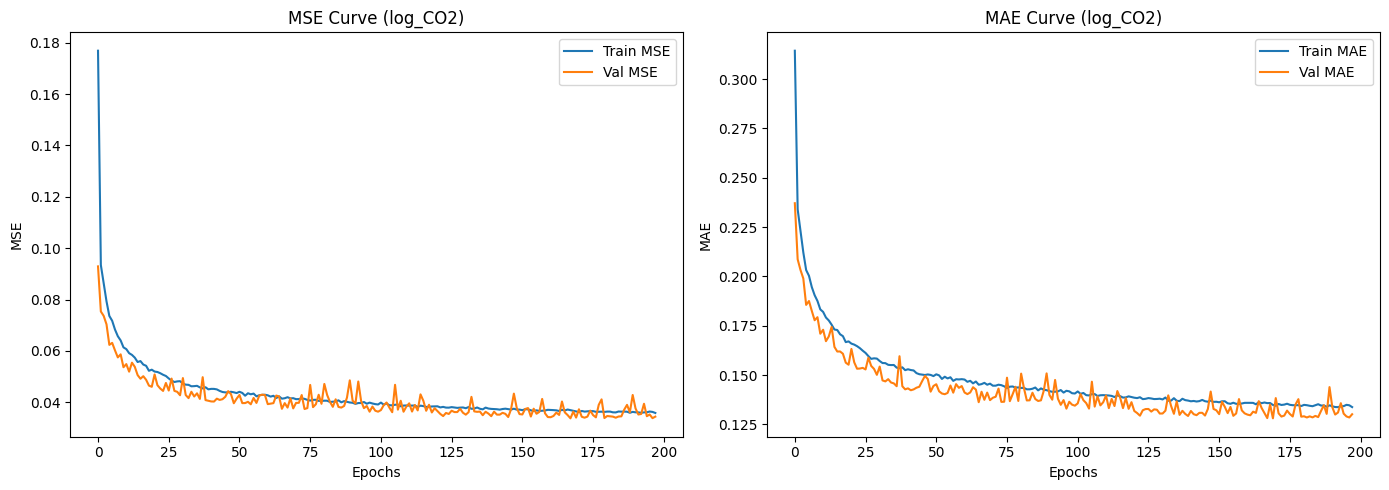

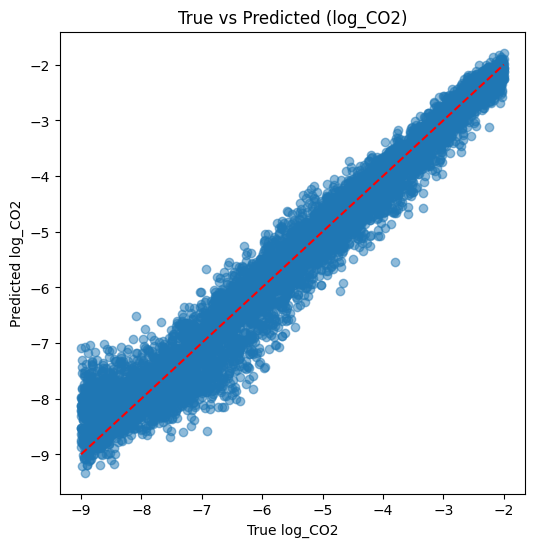

In [ ]:
# 6. Plot training curves and predictions
plot_results(history, y_true_rescaled, y_pred_rescaled, target_name=target)

In [ ]:
# 7. Predict random test samples
predict_random_samples(model, X_test, y_test, scaler_y=scaler_y, n_samples=20)


Predictions for 20 Random Test Samples:
Sample 1: True=-6.4127, Pred=-6.3104
Sample 2: True=-3.8518, Pred=-3.8540
Sample 3: True=-4.2188, Pred=-5.0804
Sample 4: True=-8.0892, Pred=-7.8505
Sample 5: True=-8.1917, Pred=-7.9351
Sample 6: True=-6.2045, Pred=-6.5301
Sample 7: True=-7.9391, Pred=-7.5649
Sample 8: True=-8.4559, Pred=-8.0412
Sample 9: True=-6.6096, Pred=-6.4821
Sample 10: True=-7.7961, Pred=-7.5332
Sample 11: True=-2.8836, Pred=-2.8375
Sample 12: True=-3.0903, Pred=-3.1501
Sample 13: True=-5.3135, Pred=-5.5036
Sample 14: True=-5.1634, Pred=-5.0169
Sample 15: True=-8.2285, Pred=-7.3184
Sample 16: True=-5.9695, Pred=-5.1609
Sample 17: True=-2.7089, Pred=-2.6299
Sample 18: True=-5.0269, Pred=-5.1599
Sample 19: True=-5.8727, Pred=-5.8975
Sample 20: True=-2.5906, Pred=-2.7835


# **log_CO**

In [ ]:
target = "log_CO"

# 1. Prepare data
X_train, X_val, X_test, y_train, y_val, y_test, scaler_X, scaler_y = prepare_data(df, target)

# 2. Create DataLoaders
batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)

# 3. Build the classical model
model = build_classical_model(input_dim=8)

In [ ]:
# 4. Train the classical model
model, history = train_classical_model(model, train_loader, val_loader, target_name=target,
                                       epochs=300, lr=0.0005, patience=30, save_dir="/content/drive/MyDrive/")

Epoch 1/300, Train MSE=0.7107, Val MSE=0.5822, Train MAE=0.6980, Val MAE=0.6158
Epoch 2/300, Train MSE=0.5895, Val MSE=0.5280, Train MAE=0.6185, Val MAE=0.5864
Epoch 3/300, Train MSE=0.5592, Val MSE=0.5039, Train MAE=0.5973, Val MAE=0.5669
Epoch 4/300, Train MSE=0.5453, Val MSE=0.5022, Train MAE=0.5878, Val MAE=0.5646
Epoch 5/300, Train MSE=0.5374, Val MSE=0.4850, Train MAE=0.5808, Val MAE=0.5567
Epoch 6/300, Train MSE=0.5256, Val MSE=0.4870, Train MAE=0.5735, Val MAE=0.5449
Epoch 7/300, Train MSE=0.5158, Val MSE=0.4653, Train MAE=0.5658, Val MAE=0.5392
Epoch 8/300, Train MSE=0.5093, Val MSE=0.4620, Train MAE=0.5614, Val MAE=0.5361
Epoch 9/300, Train MSE=0.5049, Val MSE=0.4689, Train MAE=0.5582, Val MAE=0.5460
Epoch 10/300, Train MSE=0.4987, Val MSE=0.4485, Train MAE=0.5534, Val MAE=0.5224
Epoch 11/300, Train MSE=0.4921, Val MSE=0.4413, Train MAE=0.5491, Val MAE=0.5205
Epoch 12/300, Train MSE=0.4886, Val MSE=0.4469, Train MAE=0.5457, Val MAE=0.5233
Epoch 13/300, Train MSE=0.4864, Val M

In [ ]:
# 5. Compute test metrics
metrics, y_pred_rescaled, y_true_rescaled = compute_metrics(model, X_test, y_test, scaler_y=scaler_y)


Test Metrics:
RMSE=1.216, MAE=0.914, R²=0.641


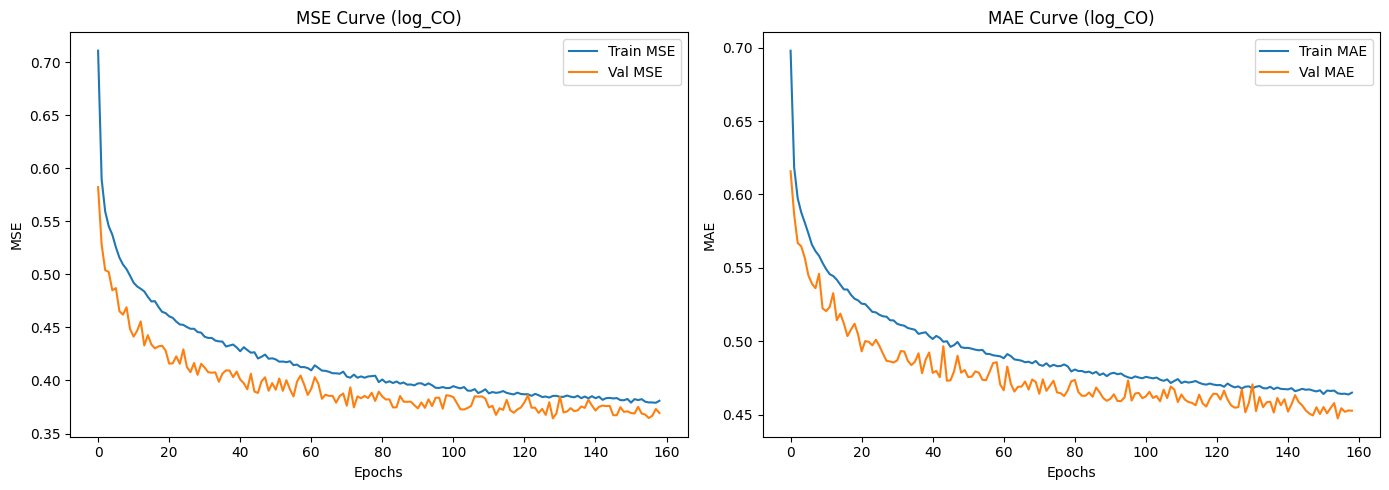

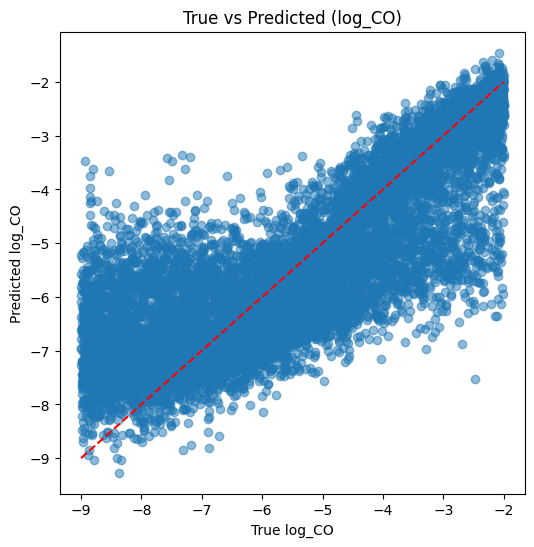

In [ ]:
# 6. Plot training curves and predictions
plot_results(history, y_true_rescaled, y_pred_rescaled, target_name=target)

In [ ]:
# 7. Predict random test samples
predict_random_samples(model, X_test, y_test, scaler_y=scaler_y, n_samples=20)


Predictions for 20 Random Test Samples:
Sample 1: True=-4.3978, Pred=-4.5035
Sample 2: True=-5.6617, Pred=-6.6443
Sample 3: True=-7.5539, Pred=-7.1503
Sample 4: True=-2.1021, Pred=-2.5177
Sample 5: True=-6.2911, Pred=-7.1850
Sample 6: True=-4.6263, Pred=-4.3201
Sample 7: True=-5.0260, Pred=-3.7753
Sample 8: True=-7.6741, Pred=-7.3802
Sample 9: True=-6.0351, Pred=-6.4239
Sample 10: True=-8.9130, Pred=-6.1717
Sample 11: True=-4.5865, Pred=-6.8632
Sample 12: True=-3.2890, Pred=-3.6258
Sample 13: True=-5.7215, Pred=-6.9644
Sample 14: True=-4.7203, Pred=-4.1738
Sample 15: True=-6.1178, Pred=-6.5432
Sample 16: True=-3.4104, Pred=-2.7341
Sample 17: True=-6.2338, Pred=-5.5110
Sample 18: True=-2.0832, Pred=-2.0001
Sample 19: True=-2.0093, Pred=-2.3227
Sample 20: True=-8.9762, Pred=-5.7475


# **log_CH4**

In [ ]:
target = "log_CH4"

# 1. Prepare data
X_train, X_val, X_test, y_train, y_val, y_test, scaler_X, scaler_y = prepare_data(df, target)

# 2. Create DataLoaders
batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)

# 3. Build the classical model
model = build_classical_model(input_dim=8)

In [ ]:
# 4. Train the classical model
model, history = train_classical_model(model, train_loader, val_loader, target_name=target,
                                       epochs=300, lr=0.0005, patience=30, save_dir="/content/drive/MyDrive/")

Epoch 1/300, Train MSE=0.2604, Val MSE=0.1801, Train MAE=0.3897, Val MAE=0.3202
Epoch 2/300, Train MSE=0.1859, Val MSE=0.1649, Train MAE=0.3203, Val MAE=0.3027
Epoch 3/300, Train MSE=0.1721, Val MSE=0.1535, Train MAE=0.3062, Val MAE=0.2897
Epoch 4/300, Train MSE=0.1646, Val MSE=0.1504, Train MAE=0.2971, Val MAE=0.2860
Epoch 5/300, Train MSE=0.1595, Val MSE=0.1545, Train MAE=0.2917, Val MAE=0.2864
Epoch 6/300, Train MSE=0.1561, Val MSE=0.1454, Train MAE=0.2870, Val MAE=0.2772
Epoch 7/300, Train MSE=0.1526, Val MSE=0.1406, Train MAE=0.2838, Val MAE=0.2701
Epoch 8/300, Train MSE=0.1524, Val MSE=0.1390, Train MAE=0.2823, Val MAE=0.2673
Epoch 9/300, Train MSE=0.1471, Val MSE=0.1377, Train MAE=0.2771, Val MAE=0.2670
Epoch 10/300, Train MSE=0.1442, Val MSE=0.1375, Train MAE=0.2739, Val MAE=0.2623
Epoch 11/300, Train MSE=0.1437, Val MSE=0.1356, Train MAE=0.2729, Val MAE=0.2625
Epoch 12/300, Train MSE=0.1411, Val MSE=0.1320, Train MAE=0.2697, Val MAE=0.2574
Epoch 13/300, Train MSE=0.1399, Val M

In [ ]:
# 5. Compute test metrics
metrics, y_pred_rescaled, y_true_rescaled = compute_metrics(model, X_test, y_test, scaler_y=scaler_y)


Test Metrics:
RMSE=0.642, MAE=0.440, R²=0.900


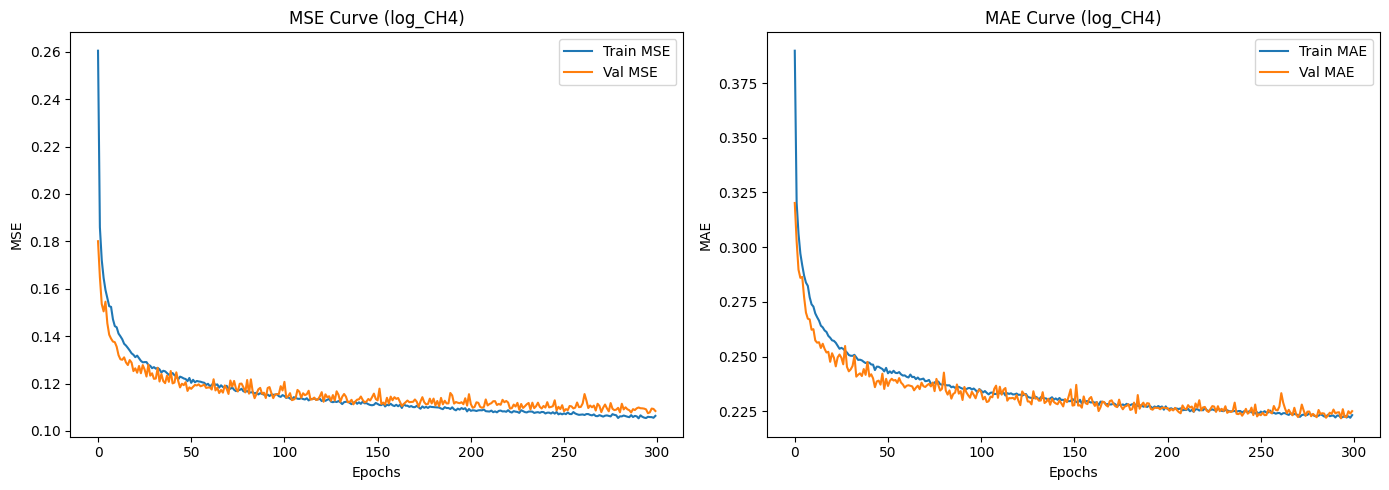

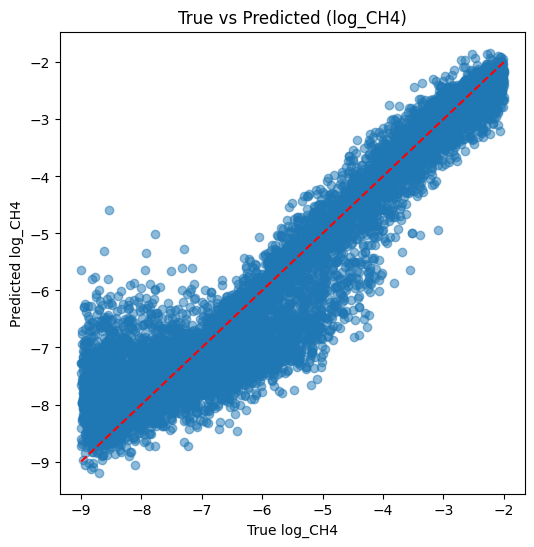

In [ ]:
# 6. Plot training curves and predictions
plot_results(history, y_true_rescaled, y_pred_rescaled, target_name=target)

In [ ]:
# 7. Predict random test samples
predict_random_samples(model, X_test, y_test, scaler_y=scaler_y, n_samples=20)


Predictions for 20 Random Test Samples:
Sample 1: True=-6.9832, Pred=-7.4903
Sample 2: True=-2.2836, Pred=-2.4726
Sample 3: True=-3.0253, Pred=-3.8154
Sample 4: True=-6.8552, Pred=-6.8245
Sample 5: True=-4.4825, Pred=-4.5369
Sample 6: True=-3.8679, Pred=-3.7752
Sample 7: True=-4.3920, Pred=-4.7321
Sample 8: True=-6.1520, Pred=-6.1044
Sample 9: True=-5.5468, Pred=-4.9550
Sample 10: True=-2.6678, Pred=-2.7430
Sample 11: True=-6.2229, Pred=-6.2676
Sample 12: True=-8.7940, Pred=-8.7533
Sample 13: True=-3.2208, Pred=-3.0930
Sample 14: True=-5.2159, Pred=-5.4690
Sample 15: True=-2.4711, Pred=-2.7160
Sample 16: True=-4.5910, Pred=-4.6578
Sample 17: True=-3.7159, Pred=-3.9014
Sample 18: True=-6.0079, Pred=-6.1831
Sample 19: True=-4.3155, Pred=-4.6305
Sample 20: True=-3.4690, Pred=-3.3310


# **log_NH3**

In [ ]:
target = "log_NH3"

# 1. Prepare data
X_train, X_val, X_test, y_train, y_val, y_test, scaler_X, scaler_y = prepare_data(df, target)

# 2. Create DataLoaders
batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)

# 3. Build the classical model
model = build_classical_model(input_dim=8)

In [ ]:
# 4. Train the classical model
model, history = train_classical_model(model, train_loader, val_loader, target_name=target,
                                       epochs=300, lr=0.0005, patience=30, save_dir="/content/drive/MyDrive/")

Epoch 1/300, Train MSE=0.2927, Val MSE=0.1918, Train MAE=0.4187, Val MAE=0.3388
Epoch 2/300, Train MSE=0.2081, Val MSE=0.1757, Train MAE=0.3465, Val MAE=0.3217
Epoch 3/300, Train MSE=0.1954, Val MSE=0.1684, Train MAE=0.3328, Val MAE=0.3096
Epoch 4/300, Train MSE=0.1888, Val MSE=0.1663, Train MAE=0.3249, Val MAE=0.3029
Epoch 5/300, Train MSE=0.1838, Val MSE=0.1608, Train MAE=0.3190, Val MAE=0.2973
Epoch 6/300, Train MSE=0.1780, Val MSE=0.1546, Train MAE=0.3130, Val MAE=0.2895
Epoch 7/300, Train MSE=0.1750, Val MSE=0.1576, Train MAE=0.3092, Val MAE=0.2938
Epoch 8/300, Train MSE=0.1708, Val MSE=0.1517, Train MAE=0.3045, Val MAE=0.2881
Epoch 9/300, Train MSE=0.1679, Val MSE=0.1496, Train MAE=0.3014, Val MAE=0.2874
Epoch 10/300, Train MSE=0.1660, Val MSE=0.1462, Train MAE=0.2992, Val MAE=0.2810
Epoch 11/300, Train MSE=0.1650, Val MSE=0.1488, Train MAE=0.2979, Val MAE=0.2844
Epoch 12/300, Train MSE=0.1625, Val MSE=0.1461, Train MAE=0.2952, Val MAE=0.2807
Epoch 13/300, Train MSE=0.1596, Val M

In [ ]:
# 5. Compute test metrics
metrics, y_pred_rescaled, y_true_rescaled = compute_metrics(model, X_test, y_test, scaler_y=scaler_y)


Test Metrics:
RMSE=0.695, MAE=0.487, R²=0.880


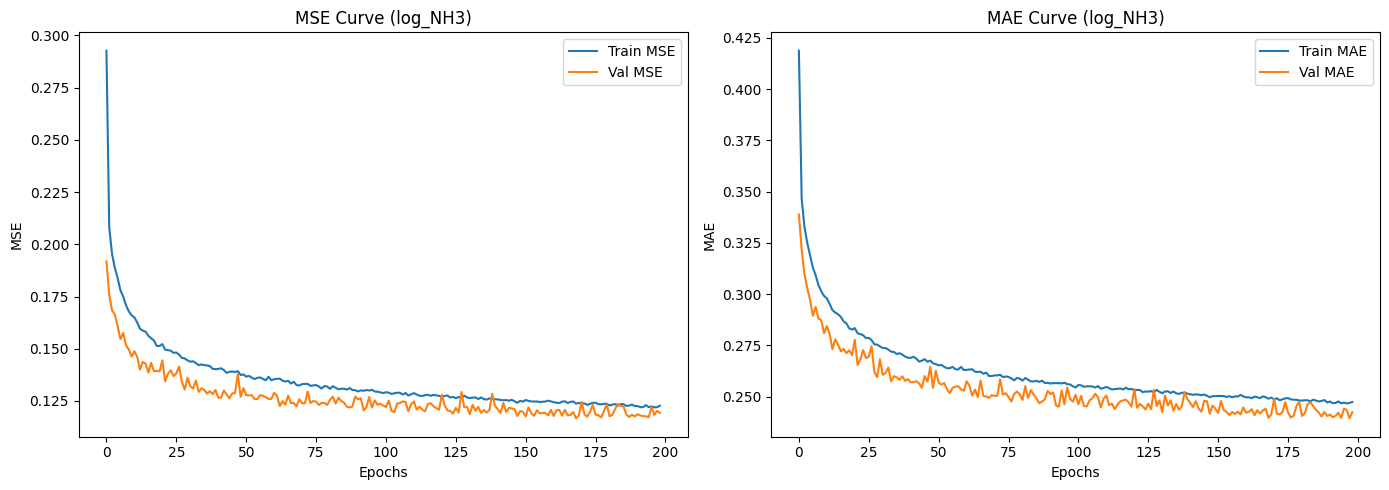

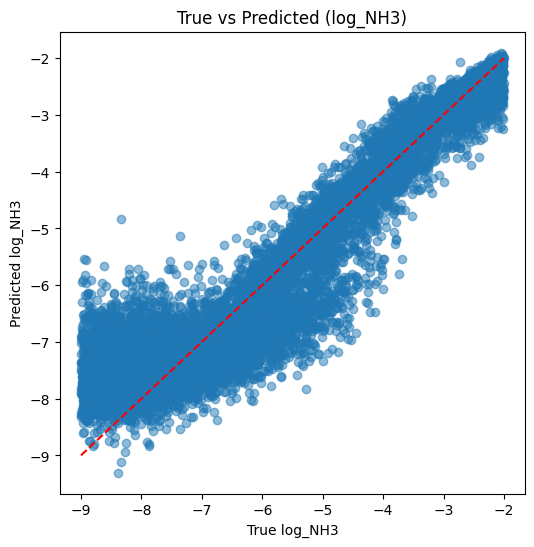

In [ ]:
# 6. Plot training curves and predictions
plot_results(history, y_true_rescaled, y_pred_rescaled, target_name=target)

In [ ]:
# 7. Predict random test samples
predict_random_samples(model, X_test, y_test, scaler_y=scaler_y, n_samples=20)


Predictions for 20 Random Test Samples:
Sample 1: True=-4.9262, Pred=-4.8873
Sample 2: True=-8.4884, Pred=-8.0018
Sample 3: True=-3.8514, Pred=-3.8485
Sample 4: True=-3.2209, Pred=-3.1556
Sample 5: True=-3.9912, Pred=-3.5020
Sample 6: True=-2.9334, Pred=-3.0065
Sample 7: True=-7.9534, Pred=-7.5147
Sample 8: True=-4.4207, Pred=-4.3458
Sample 9: True=-3.5330, Pred=-3.6792
Sample 10: True=-6.4180, Pred=-5.9288
Sample 11: True=-2.7584, Pred=-3.0536
Sample 12: True=-7.7083, Pred=-6.7153
Sample 13: True=-5.9128, Pred=-7.0946
Sample 14: True=-5.8585, Pred=-6.5235
Sample 15: True=-5.2184, Pred=-6.4699
Sample 16: True=-5.7600, Pred=-6.3984
Sample 17: True=-5.2210, Pred=-5.0055
Sample 18: True=-8.6264, Pred=-5.6629
Sample 19: True=-6.9062, Pred=-6.7464
Sample 20: True=-4.9411, Pred=-4.7817


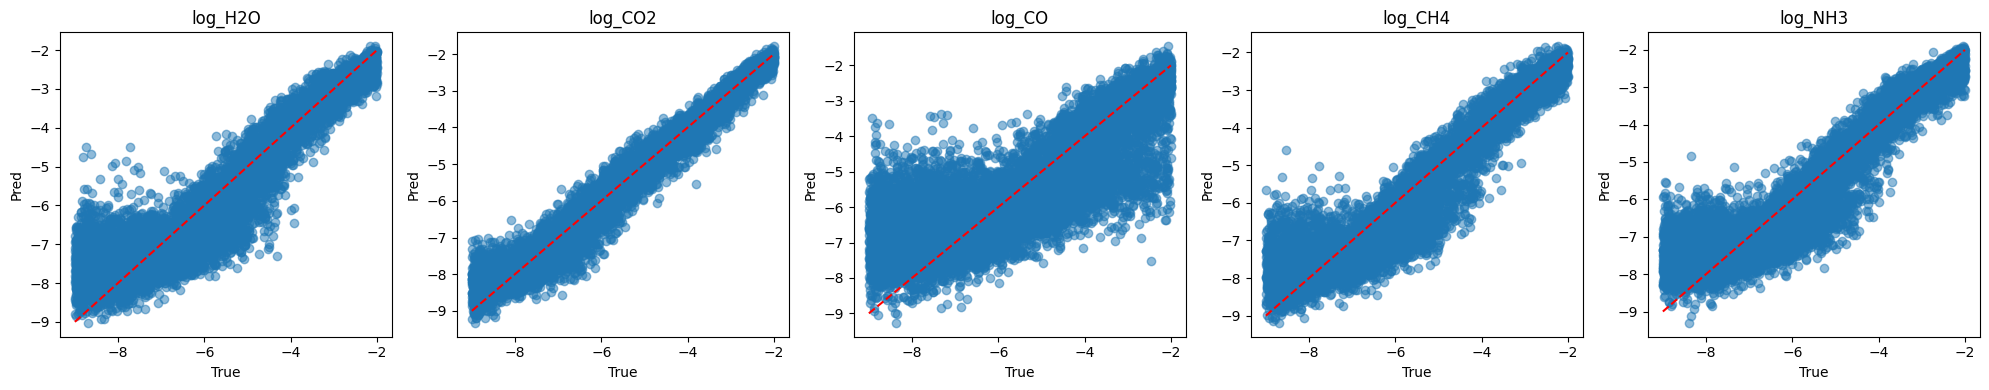

In [ ]:
targets = ["log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3"]

fig, axes = plt.subplots(1, len(targets), figsize=(20, 4))

for i, target in enumerate(targets):
    # Reload data and model
    X_train, X_val, X_test, y_train, y_val, y_test, scaler_X, scaler_y = prepare_data(df, target)
    model = build_classical_model(input_dim=8)
    model.load_state_dict(torch.load(f"/content/drive/MyDrive/classical_best_{target}.pth"))
    model.eval()

    with torch.no_grad():
        y_pred = model(X_test).numpy()
        y_true = y_test.numpy()
        if scaler_y is not None:
            y_pred = scaler_y.inverse_transform(y_pred)
            y_true = scaler_y.inverse_transform(y_true)

    # Scatter plot
    axes[i].scatter(y_true, y_pred, alpha=0.5)
    axes[i].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    axes[i].set_xlabel("True")
    axes[i].set_ylabel("Pred")
    axes[i].set_title(target)

plt.tight_layout()
plt.show()